# Tutorial 3: Model Diagnosis

This tutorial covers diagnosing whether your trained model learned meaningful regulatory patterns.

## Learning Objectives

After completing this tutorial, you will be able to:

- Evaluate training success through loss curves and weight distributions
- Visualize enhancer activity distributions
- Examine cell-type clustering in latent TF activity space
- Analyze TF activity profiles per cell-type
- Identify signs of a well-trained vs. poorly-trained model

## Setup

In [3]:
import torch

import deepscenic as ds

print(f"deepSCENIC version: {ds.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

deepSCENIC version: 0.1.0
Using device: cuda


## Load Model and Data

In [6]:
import torch.nn as nn

class DeepMEL2Embeddings(nn.Module):
    """
    PyTorch port of DeepMEL2 for sequence embeddings.

    Extracts 256-dimensional embeddings from the dense_1 layer,
    averaging forward and reverse complement strand outputs.

    Args:
        seq_len: Input sequence length (default 500, can use 640)
        embedding_dim: Output embedding dimension (default 256)
    """

    def __init__(self, seq_len: int = 500, embedding_dim: int = 256):
        super().__init__()
        self.seq_len = seq_len
        self.embedding_dim = embedding_dim

        # Conv1D: 300 filters, kernel=30, valid padding
        # Keras valid padding = no padding, output shrinks by kernel-1
        self.conv = nn.Conv1d(
            in_channels=4,
            out_channels=300,
            kernel_size=30,
            padding=0,  # valid padding
        )

        # MaxPool1D: pool=15, stride=5
        self.pool = nn.MaxPool1d(kernel_size=15, stride=5)

        # Dropout after pooling
        self.dropout1 = nn.Dropout(0.2)

        # TimeDistributed Dense: 300 -> 128
        # In PyTorch, we apply a Linear layer to the last dim
        self.linear1 = nn.Linear(300, 128)

        # Bidirectional LSTM: 128 units each direction
        # return_sequences=True means batch_first output shape is (batch, seq, 2*hidden)
        self.lstm = nn.LSTM(input_size=128, hidden_size=128, num_layers=1, batch_first=True, bidirectional=True)

        # Dropout after LSTM
        self.dropout2 = nn.Dropout(0.2)

        # Calculate flatten dimension
        # After Conv1D (valid): seq_len - 29
        # After MaxPool1D: (seq_len - 29 - 15) // 5 + 1
        after_conv = seq_len - 29
        after_pool = (after_conv - 15) // 5 + 1
        self.flatten_dim = after_pool * 256  # BiLSTM output is 256 (128*2)

        # Dense: flatten_dim -> 256 (embedding layer)
        self.fc = nn.Linear(self.flatten_dim, embedding_dim)

    def _forward_pass(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the network (single strand).

        Args:
            x: Input tensor of shape (batch, seq_len, 4)

        Returns:
            Embeddings of shape (batch, embedding_dim)
        """
        # x: (batch, seq_len, 4)

        # Conv1D expects (batch, channels, seq_len)
        x = x.transpose(1, 2)  # (batch, 4, seq_len)

        # Conv + ReLU
        x = torch.relu(self.conv(x))  # (batch, 300, seq_len-29)

        # MaxPool
        x = self.pool(x)  # (batch, 300, pooled_len)

        # Dropout
        x = self.dropout1(x)

        # Transpose for TimeDistributed Dense
        x = x.transpose(1, 2)  # (batch, pooled_len, 300)

        # TimeDistributed Dense + ReLU
        x = torch.relu(self.linear1(x))  # (batch, pooled_len, 128)

        # Bidirectional LSTM
        x, _ = self.lstm(x)  # (batch, pooled_len, 256)

        # Dropout
        x = self.dropout2(x)

        # Flatten
        x = x.flatten(1)  # (batch, pooled_len * 256)

        # Dense + ReLU -> embeddings
        x = torch.relu(self.fc(x))  # (batch, embedding_dim)

        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass with reverse complement averaging.

        Args:
            x: Input tensor of shape (batch, seq_len, 4)
               One-hot encoded DNA: [A, C, G, T]

        Returns:
            Embeddings of shape (batch, embedding_dim)
        """
        # Process forward strand
        fwd = self._forward_pass(x)

        # Process reverse complement
        # Reverse sequence (dim 1) and complement bases (dim 2)
        # Complement: A<->T, C<->G means reverse the one-hot order
        rc = torch.flip(x, dims=[1, 2])
        rc_out = self._forward_pass(rc)

        # Average forward and RC embeddings
        return (fwd + rc_out) / 2

In [7]:
# Load trained model and data
import os

data_dir = "../../../../data/deepSCENIC/MM_lines/"
assert os.path.exists(data_dir), "Data directory not found"

# Load preprocessed MuData
mdata = ds.read(data_dir + "preprocessed_data.h5mu")

sequence_model = DeepMEL2Embeddings()
model = ds.tl.load_model(data_dir + "weights/model.pt", device=device, sequence_model=sequence_model)

deepscenic.io - INFO - Loaded ../../../../data/deepSCENIC/MM_lines/preprocessed_data.h5mu: 936 cells, 10421 genes, 281820 regions
deepscenic.tl - INFO - Loaded model from ../../../../data/deepSCENIC/MM_lines/weights/model.pt: 10421 genes, 1288 TFs, 281820 regions


## Training Loss Curves

The first diagnostic is examining the training loss curves. A well-trained model should show:

- Decreasing loss over epochs
- Convergence (flattening) towards the end
- Similar train/test loss (no overfitting)

```{note}
If the test loss starts increasing while train loss decreases, the model may be overfitting.
Consider using fewer epochs or increasing regularization (`alpha`, `gamma`).
```

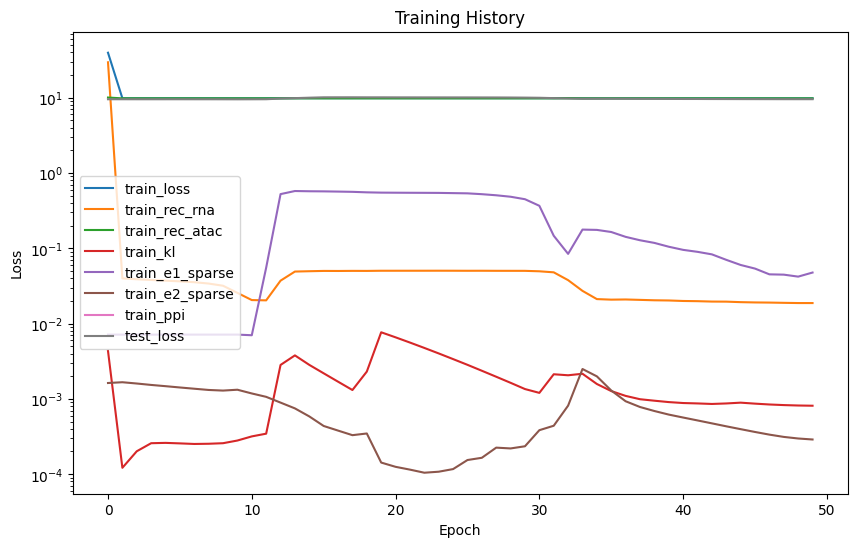

In [8]:
# Plot training loss curves
ds.pl.loss_curves(model)

## Weight Sparsity

A well-trained model should have sparse E1 and E2 matrices:

- **E1 (TF->Region)**: Most weights near zero, with a few strong TF-region connections
- **E2 (Region->Gene)**: Sparse connections reflecting biological regulation

High sparsity (>90%) indicates the model learned selective regulatory relationships rather than dense, non-specific connections.

In [ ]:
# Visualize weight distributions
# ds.pl.sparsity_histogram(model)

## Enhancer Activity Distribution

The enhancer activity distribution reveals whether the model learned meaningful activity profiles:

- A smooth, roughly normal distribution (possibly with long tails) indicates good learning
- A degenerate distribution (all zeros or uniform) suggests training issues
- Long positive tails represent highly active enhancers in specific cell types

In [ ]:
# Plot enhancer activity distribution
# ds.pl.enhancer_activity_histogram(model, mdata)

## Latent TF Activity Space

The UMAP of latent TF activity space shows whether the model captured biological variation:

- Cells should cluster by cell type or biological state
- Clear separation between different cell types indicates good learning
- Random mixing suggests the model failed to capture cell-type-specific TF activity

In [ ]:
# UMAP of latent TF activity
# Color by cell type annotation if available
# ds.pl.latent_umap(model, mdata, color="celltype")

## TF Activity by Cell Type

The clustered heatmap of TF activities per cell type reveals:

- Which TFs are active in which cell types
- Cell-type-specific TF profiles that correlate with known biology
- Whether the model learned biologically meaningful regulatory patterns

Look for:
- Known lineage-specific TFs showing high activity in expected cell types
- Distinct activity profiles between different cell types
- Clustering that matches known biological relationships

In [ ]:
# TF activity clustermap by cell type
# ds.pl.tf_activity_clustermap(model, mdata, groupby="celltype", top_n_tfs=50)

## Signs of Successful Training

A well-trained deepSCENIC model shows:

1. **Converged loss**: Training loss decreases and stabilizes
2. **Sparse weights**: >90% of E1/E2 weights near zero
3. **Structured activity**: Non-degenerate enhancer activity distribution
4. **Cell-type clustering**: Clear separation in latent space UMAP
5. **Biologically meaningful TF profiles**: Known TFs active in expected cell types

If your model shows these signs, proceed to GRN analysis in the next tutorial.

## Troubleshooting Poor Training

If diagnostics suggest poor training:

| Issue | Possible Solutions |
|-------|-------------------|
| Loss not converging | Increase epochs, reduce learning rate |
| Dense weights (low sparsity) | Increase `alpha` and `gamma` regularization |
| Degenerate activity distribution | Check data preprocessing, adjust warmup epochs |
| No cell-type clustering | Verify cell type annotations, increase training epochs |
| Test loss increasing | Reduce epochs (early stopping), increase regularization |

## Next Steps

Once you've confirmed successful training, proceed to:

- Extract and analyze the learned GRN: {doc}`04_grn_analysis`
- Create advanced visualizations: {doc}`05_visualization`